In [1]:
!pwd
import sys
import types

# Import the real anchored_artists module
import mpl_toolkits.axes_grid1.anchored_artists as anchored_artists

# If AnchoredEllipse doesn't exist, define a dummy version
if not hasattr(anchored_artists, "AnchoredEllipse"):
    print("AnchoredEllipse not found – faking it to avoid import errors.")

    class AnchoredEllipse:
        def __init__(*args, **kwargs):
            raise NotImplementedError("AnchoredEllipse is not implemented – skipping.")

    anchored_artists.AnchoredEllipse = AnchoredEllipse

/Users/macbook/divtel/MST
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
AnchoredEllipse not found – faking it to avoid import errors.


In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%reload_ext autoreload
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import sys
from ipywidgets import interactive, FloatSlider, interact, fixed
from divtel import *
from adjustText import adjust_text

import copy
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroplan.plots import plot_sky
from astroplan import FixedTarget
#from . import utils
#from .const import COLORS
#from . import pointing

from matplotlib.transforms import Affine2D
from astropy.visualization.wcsaxes import SphericalCircle

import healpy as hp
import tqdm
from astropy.coordinates import Angle
#!jupyter labextension install @jupyter-widgets/jupyterlab-manager

The Idea is to have two notebooks, one for MST configuration confronting just one altitude and the other for them changing with zenith
This one should be just for one altitude 

## LOAD CTA CONFIG

In [3]:
cta = CTA_Info('south')

Observer         :  CTA South
Location         :  Paranal , (1946.635798, -5467.63394562, -2642.49852123) km
Observation time :  2025-08-15T19:46:28.809


In [4]:
# Note that if the radius is in meters, 
# you can set LoadConfig(file, radius="meters")
# defalut is in degrees

array = LoadConfig("/Users/macbook/divtel/ParanalArrayPositions_divProd6.txt", frame=cta)
full_array= LoadConfig("/Users/macbook/divtel/Paranal_only_MST.txt", frame=cta)

## Check configuration table

In [5]:
array.table.units = "deg"
array.table
full_array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,rad,rad,rad,m,m,rad2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,0.0,24.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,22.65
2,0.0,151.0,25.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,152.67
3,0.0,-151.0,31.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,152.68
4,150.0,75.0,21.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,188.09
5,150.0,-75.0,26.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,187.98
6,150.0,240.0,24.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,295.50
7,150.0,-240.0,30.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,295.49
8,313.0,0.0,19.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,335.47


In [6]:
table=array.table

## Check the telescope spatial distribution
This is useful to pick the groups

In [7]:
array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,-20.0,-65.0,34.0,0.000,0.000,90.000,28.000,2.150,14.536,1.000,-0.000,0.000,66.52
2,80.0,0.0,29.0,0.000,0.000,90.000,28.000,2.150,14.536,1.000,-0.000,0.000,86.67
3,-20.0,65.0,31.0,0.000,0.000,90.000,28.000,2.150,14.536,1.000,-0.000,0.000,66.37
4,-120.0,0.0,33.0,0.000,0.000,90.000,28.000,2.150,14.536,1.000,-0.000,0.000,113.39
5,0.0,0.0,24.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,8.55
6,0.0,151.0,25.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,151.21
7,0.0,-151.0,31.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,151.16
8,150.0,75.0,21.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,173.90


In [16]:
full_array.divergent_pointing(0.014, az=0,alt=70)

The barycenter -22.357142857142858
The barycenter 0.0
The barycenter 27.642857142857142


-626.0 -626.0 51.24
-626.0 -626.0 1303.24
-626.0 626.0 51.24
-626.0 626.0 1303.24
626.0 -626.0 51.24
626.0 -626.0 1303.24
626.0 626.0 51.24
626.0 626.0 1303.24


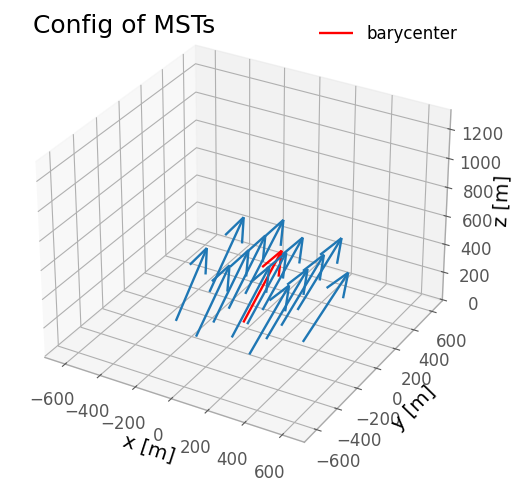

In [18]:
ax = full_array.display("xyz")



#ax.legend(by_label.values(), by_label.keys(), loc='lower left')
ax.text2D(0.05, 0.95, "Config of MSTs", 
          transform=ax.transAxes, fontsize=18)



plt.show()

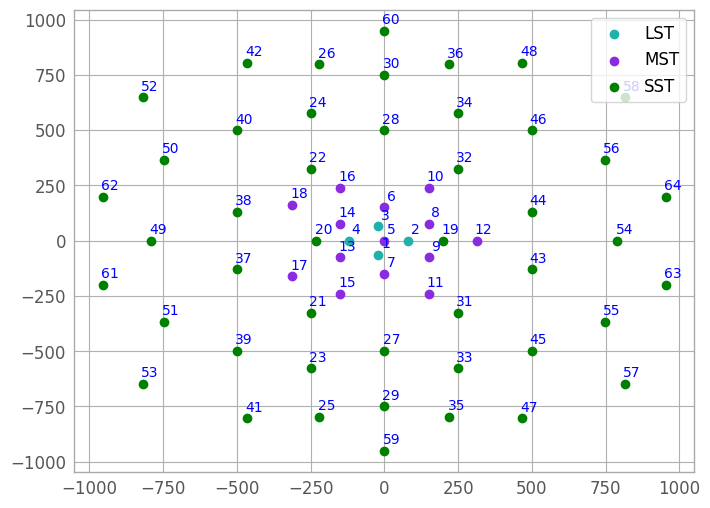

In [158]:
# Loop through all the telescopes
#for fov in array.table["fov"]:
#    print(fov)
colors = [
    'lightseagreen' if np.isclose(fov, 14.5356) else
    'blueviolet' if np.isclose(fov, 46.707) else 
    'green' if np.isclose(fov, 62.462) else
    'red'  # Default color if none of the conditions match
    for fov in array.table["fov"]
]
fov_labels = {
    'lightseagreen': 'LST',
    'blueviolet': 'MST',
    'green': 'SST'
}
for i in range(len(array.table)):
    plt.scatter(array.table['x'][i], array.table['y'][i], c=colors[i], label=fov_labels[colors[i]])

    # Annotate each point with the telescope ID
    #matplotlib.pyplot.annotate(text, xy, xytext=None, xycoords='data', textcoords=None, arrowprops=None, annotation_clip=None, **kwargs)
#Annotate the point xy with text text.
#In the simplest form, the text is placed at xy.
    plt.annotate(str(array.table["id"][i]),
                 (array.table['x'][i], array.table['y'][i]),  # Point position
                 textcoords="offset points",  # Text position relative to the point
                 xytext=(5, 5),  # Offset in pixels (to avoid overlapping the point)
                 ha='center', fontsize=10, color='blue')
handles, labels = plt.gca().get_legend_handles_labels()
#handles, labels like this is doing
    #plt.gca() gets the current Axes object, which is where your plot is
    #.get_legend_handles_labels()
        #handles: Returns a list of the graphical elements (e.g., lines, scatter plot points) that would appear in the legend.
        # labels: Returns the text labels associated with each graphical element in handles

by_label = dict(zip(labels, handles))  # Remove duplicate labels, the dictionary by the structure takes out the double 
plt.legend(by_label.values(), by_label.keys())
#by_label.values This is pulling out the unique graphical elements
# by_label.keys  This is retrieving the unique text 
plt.savefig("./different_telescopes.png", dpi=300, bbox_inches="tight")
plt.show() 

## Check the hyper field of view (hFoV)

This is the whole telescope array hFoV maybe? (ask)

In [159]:
array.hFoV(m_cut=3) 

64it [00:09,  6.59it/s]


(62.238869377690584, 57.415086388537716)

In [160]:
#array.hFoV(m_cut=3)

## Grouping telescopes

In [161]:
sub_groups={'1':[7,8,11], 
            '2': [5,13,16,18],
            '3': [14,15,17], 
            '4': [6,10,12,9]}


In [162]:
def compute_center_of_gravity(group):
    x, y, z = group['x'], group['y'], group['z']
    cog_x = round(np.mean(x),2)
    cog_y = round(np.mean(y),2)
    cog_z = round(np.mean(z),2)
    return cog_x, cog_y, cog_z

# Function to create new telescope list with center of gravity
def create_new_group_list(tel_group):
    new_telescopes = []
    for group in tel_group.groups:
        print(tel_group.groups)
        print (group['focal'][0],round(group['radius'][0],2))
        #id_ = group["id"][0]
        cog = compute_center_of_gravity(group)
        focal, fov = group['focal'][0], round(group['radius'][0],2)  # Assuming same within a group
        new_telescopes.append([*cog, focal, fov])
    return new_telescopes


In [163]:
tel_group, labels, number_of_telescopes_subarray_1 =array.group_by(sub_groups)

In [164]:
# Step 2: Create new telescope list with center of gravity
new_telescopes = create_new_group_list(tel_group)



<TableGroups indices=[ 0 50 53 57 60 64]>
28.0 2.15
<TableGroups indices=[ 0 50 53 57 60 64]>
16.0 3.85
<TableGroups indices=[ 0 50 53 57 60 64]>
16.0 3.85
<TableGroups indices=[ 0 50 53 57 60 64]>
16.0 3.85
<TableGroups indices=[ 0 50 53 57 60 64]>
16.0 3.85


In [165]:
#del new_telescopes[0]# Step 3: Output the result
#for telescope in new_telescopes:
#    print(telescope)
del new_telescopes[0]#No clue why it keeps on putting me an extra telescope...soooo... I deleted it... I will find out why
for telescope in new_telescopes:
    print(telescope)

[100.0, -105.33, 27.33, 16.0, 3.85]
[-153.25, 81.75, 27.38, 16.0, 3.85]
[-204.33, -109.0, 33.83, 16.0, 3.85]
[153.25, 79.0, 23.5, 16.0, 3.85]


In [166]:
# Define the file path where you want to save the output
output_file_path = './MST_chosen_configuration.txt'

# Open the file in write mode
with open(output_file_path, 'w') as file:
    
    # Write a header
    #file.write("Group ID, X_Center, Y_Center, Z_Center, Focal Length, FOV\n")
    
    # Loop through all new telescopes (grouped telescopes)
    for i, telescope in enumerate(new_telescopes):
        # Assuming telescope is a list like [x_center, y_center, z_center, focal_length, fov]
        values = ' '.join(map(str, telescope))  # Convert all elements to string
        # Write the data to the file
        #print(values)
        file.write(f"{values}\n")

print(f"New telescope data has been written to {output_file_path}")


New telescope data has been written to ./MST_chosen_configuration.txt


## SANITY CHECK

In [167]:
#array.table

# THE FIELD OF VIEW

## GRAPHING MULTIPLICITY AND FOV to understand what is going on 

In [168]:
array= LoadConfig("./MST_chosen_configuration.txt", frame=cta, pointing2src=True)


In [169]:
array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,rad,rad,rad,m,m,rad2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,100.0,-105.33,27.33,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,156.04
2,-153.25,81.75,27.38,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,158.82
3,-204.33,-109.0,33.83,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,202.35
4,153.25,79.0,23.5,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,201.79


In [170]:
full_array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,rad,rad,rad,m,m,rad2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,0.0,24.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,22.65
2,0.0,151.0,25.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,152.67
3,0.0,-151.0,31.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,152.68
4,150.0,75.0,21.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,188.09
5,150.0,-75.0,26.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,187.98
6,150.0,240.0,24.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,295.50
7,150.0,-240.0,30.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,295.49
8,313.0,0.0,19.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,335.47


In [171]:
array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,rad,rad,rad,m,m,rad2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,100.0,-105.33,27.33,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,156.04
2,-153.25,81.75,27.38,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,158.82
3,-204.33,-109.0,33.83,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,202.35
4,153.25,79.0,23.5,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,201.79


In [172]:
full_array.divergent_pointing(0.02, az=0,alt=70)

The barycenter -22.357142857142858
The barycenter 0.0
The barycenter 27.642857142857142


## INCREASING

In [173]:
chosen_divergences=[0.0022,0.0043, 0.008, 0.01135, 0.01453, 0.01753, 0.02053, 0.02353, 0.02653, 0.02953]
FoV_array_div_chosen=[]
av_multiplicity_array_div_chosen=[]

for divergence in chosen_divergences:
    array.divergent_pointing(divergence, az=0,alt=70)    
    FoV=array.hFoV(subarray_mult=number_of_telescopes_subarray_1)[0]
    print(f"The FoV of {divergence} is {FoV}")
    multiplicity=array.hFoV(subarray_mult=number_of_telescopes_subarray_1)[1]
    print(f"The multiplicity of {divergence} is {multiplicity}")
    FoV_array_div_chosen.append(FoV)
    av_multiplicity_array_div_chosen.append(multiplicity)
    

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  7.06it/s]


The FoV of 0.0022 is 51.32805198994542


4it [00:00,  7.23it/s]


The multiplicity of 0.0022 is 12.70056208482371
The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


...

The multiplicity of 0.02653 is 5.765586903517938
The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  6.84it/s]


The FoV of 0.02953 is 121.38284343866499


4it [00:00,  7.00it/s]

The multiplicity of 0.02953 is 5.363872082973207


The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  6.35it/s]
4it [00:00,  6.58it/s]


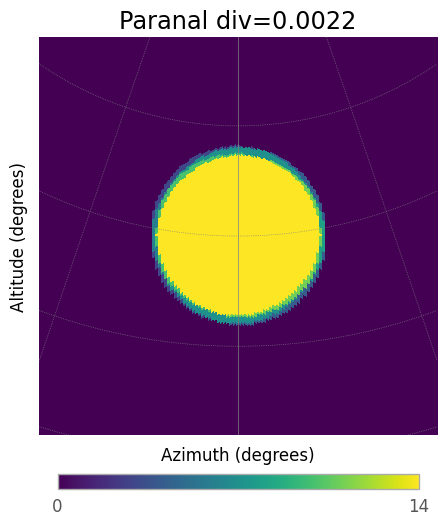

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  6.78it/s]
4it [00:00,  6.39it/s]


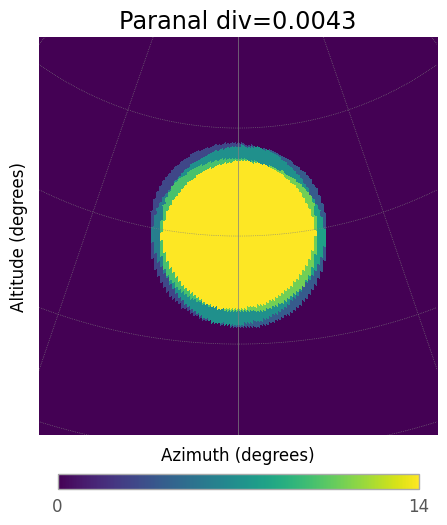

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  6.81it/s]
4it [00:00,  6.29it/s]


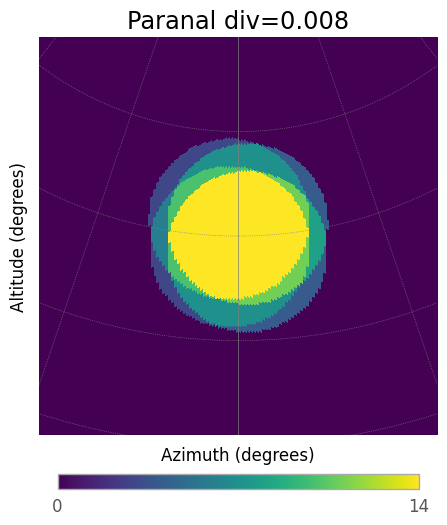

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  6.70it/s]
4it [00:00,  5.94it/s]


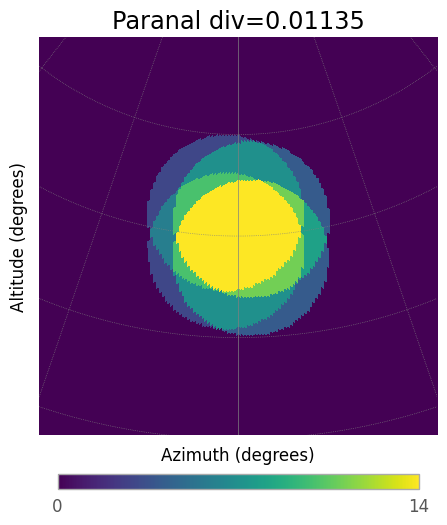

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  5.78it/s]
4it [00:00,  6.16it/s]


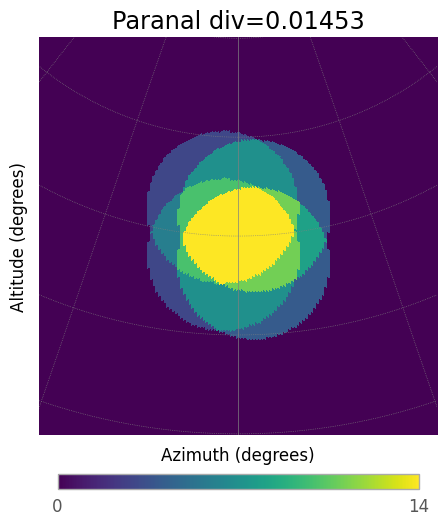

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  6.37it/s]
4it [00:00,  5.70it/s]


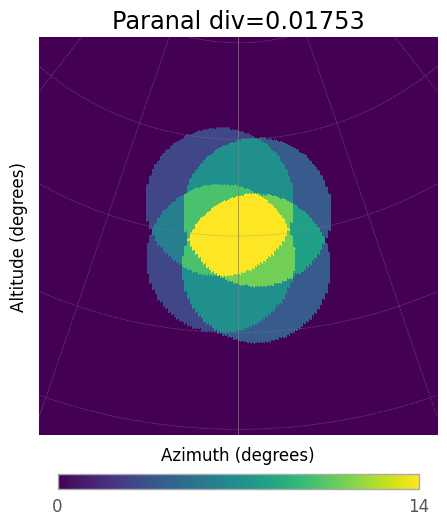

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  6.51it/s]
4it [00:00,  5.79it/s]


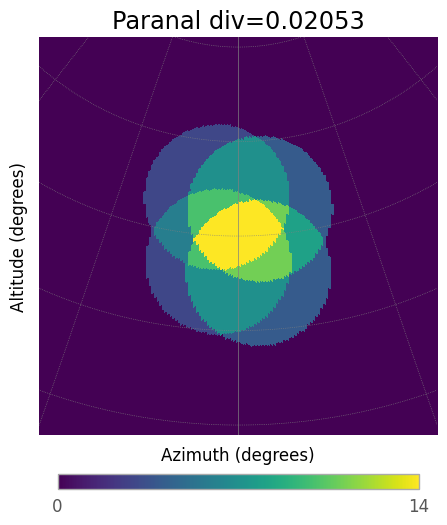

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  6.16it/s]
4it [00:00,  5.99it/s]


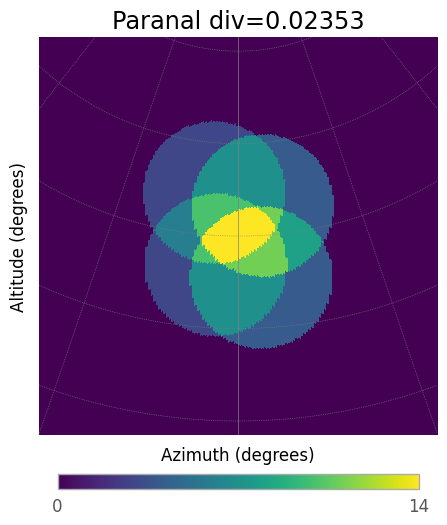

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  6.32it/s]
4it [00:00,  5.99it/s]


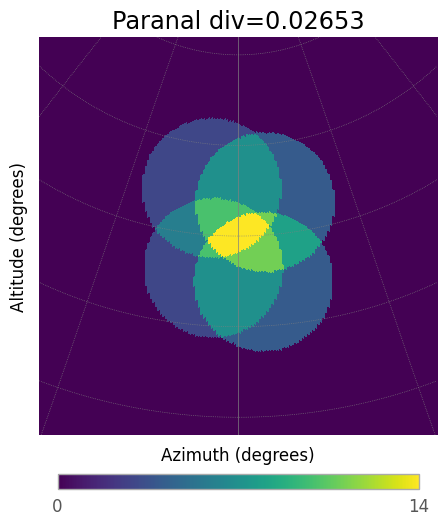

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  6.32it/s]
4it [00:00,  5.43it/s]


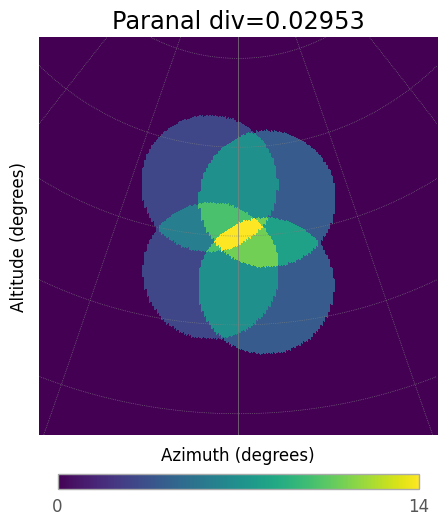

In [174]:
for divergence in chosen_divergences:
    array.divergent_pointing(div=divergence, az=0, alt=70)
    array.multiplicity_plot(number_of_telescopes_subarray_1)

In [175]:
def GRB_position(ra_start, dec_start, ra_final, dec_final):
   #Creating Sky coordinated object for the initial position
    c1 = SkyCoord(ra=ra_start * u.deg, dec=dec_start * u.deg, frame='icrs')
    c2 = SkyCoord(ra=ra_final * u.deg, dec=dec_final * u.deg, frame='icrs')
    #Now we need two thing the angular separation and the position angles(radius and theta)
    #Radius, what is the separation of this two coordianted
    separation = c1.separation(c2)
    #Theta, relative to the positions of the coordiantes what is the angle
    theta = c1.position_angle(c2)

    print(f"Separation, radius: {separation.to(u.deg):.3f}")
    print(f"Position angle(theta), altitude: {theta.to(u.deg):.3f}")
    return separation, theta
    
def multiplicity_plot(array, radius=None, subarray_mult=None, fig=None, alt=None, az=None):
    if array.table.units == 'rad':
        array.__convert_units__(toDeg=True)

    coord = array.get_pointing_coord(icrs=False)
    nside = 512
    map_multiplicity = np.zeros(hp.nside2npix(nside), dtype=np.float64)

    # Initialize Healpix coordinates
    counter = np.arange(0, hp.nside2npix(nside))
    ra, dec = hp.pix2ang(nside, counter, True, lonlat=True)
    coordinate = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)

    # If subarray_mult is not provided, set all multiplicities to 1
    if subarray_mult is None:
        subarray_mult = np.ones(len(array.telescopes))

    # Iterate over telescopes
    for i, tel in tqdm.tqdm(enumerate(array.telescopes)):
        pointing = SkyCoord(ra=coord.az[i].degree, dec=coord.alt[i].degree, unit='deg')
        r_fov = np.arctan((tel.camera_radius / tel.focal).to(u.dimensionless_unscaled)).to(u.deg)
        mask = coordinate.separation(pointing) < r_fov
        map_multiplicity[mask] += subarray_mult[i]
  
    # Plotting
    R = np.sqrt(array.hFoV(m_cut=1)[0]/np.pi) + 5
    hp.cartview(map_multiplicity,
                rot=[array.pointing["az"].value, array.pointing["alt"].value],
                lonra=[-R, R], latra=[-R, R],
                nest=True, cmap='viridis',
                title=f"{array.frame.site} div={array.div}")
    plt.annotate('Azimuth (degrees)', xy=(0.5, -0.05), xycoords='axes fraction', ha='center', va='center')
    plt.annotate('Altitude (degrees)', xy=(-0.05, 0.5), xycoords='axes fraction', ha='center', va='center', rotation='vertical')
    hp.graticule(dpar=5, dmer=5, coord='G', color='gray', lw=0.5)


    # ---- ADD A RING HERE ----
    az_center = az * u.deg
    alt_center= alt * u.deg
    center = SkyCoord(az=az_center, alt=alt_center, frame='altaz')
    angles = Angle(np.linspace(0, 2*np.pi, 200), unit=u.rad)  # Position angles around the center
    ring_radius = radius *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)

    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
  
   
    hp.projplot(lon, lat, '-', lonlat=True, linewidth=1.5, color='orange')
    print(az)
    print(alt)
##MST FoV
    ring_radius = 3.75 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)
     
    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
   
    hp.projplot(lon, lat, '-', lonlat=True, linewidth=1.5, color='red')



    ## The different telescopes
    ##GRB SHORT 
    ring_radius = 2.2 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)
     
    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
   
   # hp.projplot(lon, lat, '--', lonlat=True, linewidth=1.5, color='maroon')

    ## GRB short maximum 

    ring_radius = 4 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)
     
    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
   
   # hp.projplot(lon, lat, '--', lonlat=True, linewidth=1.5, color='maroon')

##WORST LONG GRB
    ring_radius = 5 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)

    lon = ring.az.deg
    lat = ring.alt.deg
    hp.projplot(lon, lat, '--', lonlat=True, linewidth=1.5, color='white')

    ##BEST LONG GRB
    ring_radius = 1.5 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)

    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
   
    #hp.projplot(lon, lat, '--', lonlat=True, linewidth=1.5, color='white')


    
    center = SkyCoord(az=az*u.deg, alt=alt*u.deg, frame='altaz')

    # Offset at angle θ = 45°
    theta = 0 * u.deg
    separation = 0 * u.deg
    point_on_ring = center.directional_offset_by(position_angle=theta, separation=separation)

# Plot it
    hp.projscatter(point_on_ring.az.deg, point_on_ring.alt.deg, lonlat=True,
               marker='x', color='red', s=100)
    # -------------------------- 

    plt.show()

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  6.39it/s]
4it [00:00,  6.29it/s]


0
70


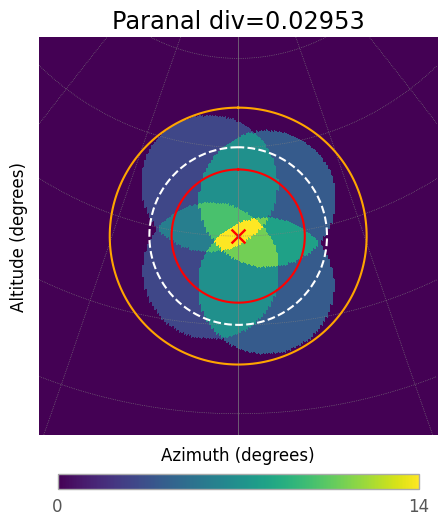

In [176]:
array.divergent_pointing(div=0.02953, az=0, alt=70)
multiplicity_plot(array, 7.23, number_of_telescopes_subarray_1, alt=70, az=0)

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998


4it [00:00,  6.34it/s]
4it [00:00,  6.31it/s]


0
70


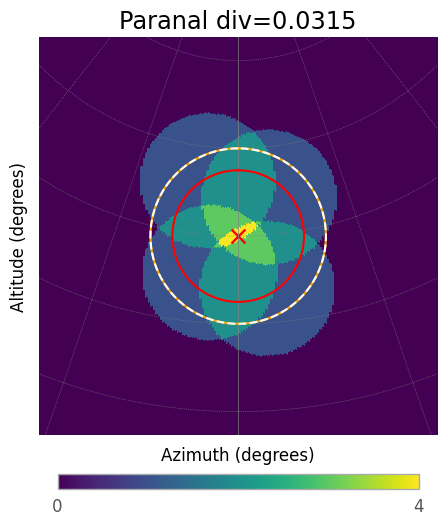

In [177]:
array.divergent_pointing(div=0.0315, az=0, alt=70)
multiplicity_plot(array, radius=5, alt=70, az=0)

In [178]:
ra_start, dec_start = 124.600,  -12.933
ra_final, dec_final = 128.100, -14.480



In [179]:
GRB_position(124.600,  -12.933, 128.100, -14.480 )

Separation, radius: 3.736 deg
Position angle(theta), altitude: 114.871 deg


(<Angle 3.73556003 deg>, <Angle 2.00487541 rad>)

In [181]:
full_array.divergent_pointing_full_array_with_subarray(subarray=array, subgroups=sub_groups, div=0.02953, az=0, alt=70)




The barycenter -22.357142857142858
The barycenter 0.0
The barycenter 27.642857142857142


TypeError: Array.divergent_pointing() got an unexpected keyword argument 'subarray'

In [195]:
for src_idx_str, target_indices in sub_groups.items():
    src_idx = int(src_idx_str) - 1  # dictionary keys start at 1
    
    for tgt_idx in target_indices:
        table_idx = tgt_idx - 5  # table starts at 0
        full_array.table['p_x'][table_idx] = array.table['p_x'][src_idx]
        full_array.table['p_y'][table_idx] = array.table['p_y'][src_idx]
        full_array.table['p_z'][table_idx] = array.table['p_z'][src_idx]
        full_array.table['zn'][table_idx] = array.table['zn'][src_idx]
        full_array.table['alt'][table_idx] = array.table['alt'][src_idx]
        full_array.table['az'][table_idx] = array.table['az'][src_idx]

In [196]:
#full_array.divergent_pointing(0.05)

In [197]:
array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,100.0,-105.33,27.33,4.340,67.828,22.172,16.000,3.850,46.707,0.376,-0.029,0.926,156.04
2,-153.25,81.75,27.38,354.329,72.101,17.899,16.000,3.850,46.707,0.306,0.030,0.952,158.82
3,-204.33,-109.0,33.83,6.017,73.024,16.976,16.000,3.850,46.707,0.290,-0.031,0.956,202.35
4,153.25,79.0,23.5,355.821,66.931,23.069,16.000,3.850,46.707,0.391,0.029,0.920,201.79


In [198]:
full_array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,0.0,24.0,354.329,72.101,17.899,16.000,3.850,46.707,0.306,0.030,0.952,22.65
2,0.0,151.0,25.0,355.821,66.931,23.069,16.000,3.850,46.707,0.391,0.029,0.920,152.67
3,0.0,-151.0,31.0,4.340,67.828,22.172,16.000,3.850,46.707,0.376,-0.029,0.926,152.68
4,150.0,75.0,21.0,4.340,67.828,22.172,16.000,3.850,46.707,0.376,-0.029,0.926,188.09
5,150.0,-75.0,26.0,355.821,66.931,23.069,16.000,3.850,46.707,0.391,0.029,0.920,187.98
6,150.0,240.0,24.0,355.821,66.931,23.069,16.000,3.850,46.707,0.391,0.029,0.920,295.50
7,150.0,-240.0,30.0,4.340,67.828,22.172,16.000,3.850,46.707,0.376,-0.029,0.926,295.49
8,313.0,0.0,19.0,355.821,66.931,23.069,16.000,3.850,46.707,0.391,0.029,0.920,335.47


In [199]:
full_array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,0.0,24.0,354.329,72.101,17.899,16.000,3.850,46.707,0.306,0.030,0.952,22.65
2,0.0,151.0,25.0,355.821,66.931,23.069,16.000,3.850,46.707,0.391,0.029,0.920,152.67
3,0.0,-151.0,31.0,4.340,67.828,22.172,16.000,3.850,46.707,0.376,-0.029,0.926,152.68
4,150.0,75.0,21.0,4.340,67.828,22.172,16.000,3.850,46.707,0.376,-0.029,0.926,188.09
5,150.0,-75.0,26.0,355.821,66.931,23.069,16.000,3.850,46.707,0.391,0.029,0.920,187.98
6,150.0,240.0,24.0,355.821,66.931,23.069,16.000,3.850,46.707,0.391,0.029,0.920,295.50
7,150.0,-240.0,30.0,4.340,67.828,22.172,16.000,3.850,46.707,0.376,-0.029,0.926,295.49
8,313.0,0.0,19.0,355.821,66.931,23.069,16.000,3.850,46.707,0.391,0.029,0.920,335.47


-626.0 -626.0 51.24
-626.0 -626.0 1303.24
-626.0 626.0 51.24
-626.0 626.0 1303.24
626.0 -626.0 51.24
626.0 -626.0 1303.24
626.0 626.0 51.24
626.0 626.0 1303.24


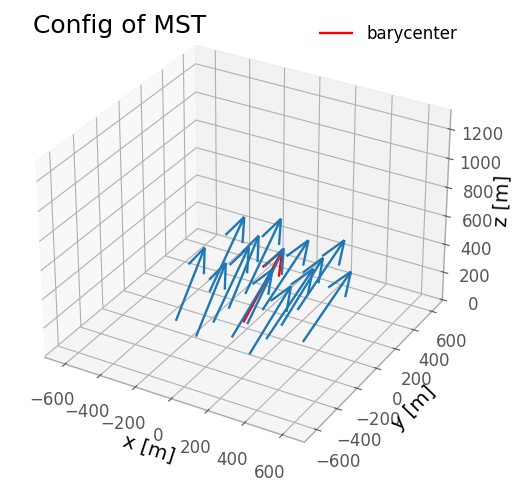

In [200]:
ax = full_array.display("xyz")



#ax.legend(by_label.values(), by_label.keys(), loc='lower left')
ax.text2D(0.05, 0.95, "Config of MST ", 
          transform=ax.transAxes, fontsize=18)



plt.show()

4it [00:00,  6.60it/s]
4it [00:00,  6.27it/s]


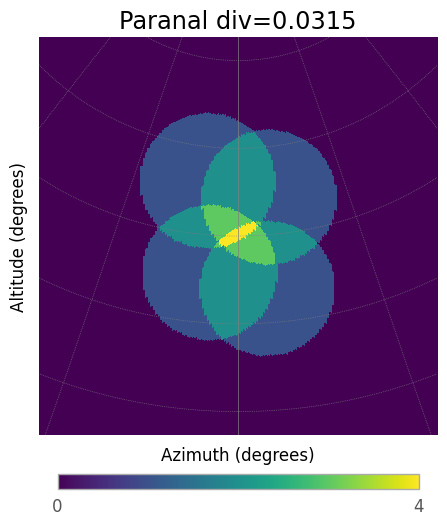

In [201]:
array.multiplicity_plot()

14it [00:02,  6.56it/s]
14it [00:02,  6.53it/s]


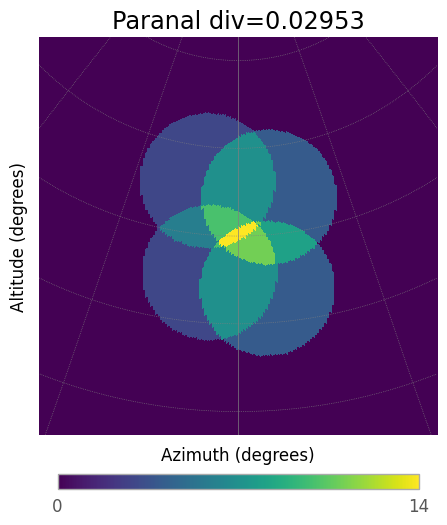

In [202]:
full_array.multiplicity_plot()

In [203]:
full_array.export_cfg(verbose=True)

#ifndef TELESCOPE

#  define TELESCOPE 0

#endif

#if TELESCOPE == 0

   TELESCOPE_THETA=20.00 

   TELESCOPE_PHI=0.00 



% Global and default configuration for things missing in telescope-specific config.

#  include <CTA-ULTRA6-LST.cfg>



#elif TELESCOPE == 1

#  include <CTA-ULTRA6-LST.cfg>

   TELESCOPE_THETA=17.90

   TELESCOPE_PHI=5.67



#elif TELESCOPE == 2

#  include <CTA-ULTRA6-LST.cfg>

   TELESCOPE_THETA=23.07

   TELESCOPE_PHI=4.18



#elif TELESCOPE == 3

#  include <CTA-ULTRA6-LST.cfg>

   TELESCOPE_THETA=22.17

   TELESCOPE_PHI=355.66



#elif TELESCOPE == 4

#  include <CTA-ULTRA6-LST.cfg>

   TELESCOPE_THETA=22.17

   TELESCOPE_PHI=355.66



#elif TELESCOPE == 5

#  include <CTA-ULTRA6-MST-NectarCam.cfg>

   TELESCOPE_THETA=23.07

   TELESCOPE_PHI=4.18



#elif TELESCOPE == 6

#  include <CTA-ULTRA6-MST-NectarCam.cfg>

   TELESCOPE_THETA=23.07

   TELESCOPE_PHI=4.18



#elif TELESCOPE == 7

#  include <CTA-ULTRA6-MST-NectarCam.cfg>

   TELESCOPE_THETA=22.17

   TEL

In [ ]:
array.multiplicity_plot()